# AB_Capacity_test

Finds, for VGGT (plain), VGGT-Omega, MegaSaM and lingbot-map, the maximum number of
input frames each technique can reconstruct before it OOMs on this GPU, and how that
ceiling shifts with input resolution.

Reuses `AA_Cam_pose_sweeps`' resumability machinery (status-CSV-before-attempt,
`resolve_stale_pending()` on kernel restart, `classify_error` OOM string-matching)
almost verbatim, but strips out everything accuracy-related -- no GPS ground truth,
no `align_and_score`, no CUT3R -- and adds a second sweep axis (resolution) that has
no precedent elsewhere in this codebase.

Split into three independently-runnable parts, same shape as `AA_Cam_pose_sweeps`:
- **Part 2 (Sweep)** is expensive and resumable -- safe to interrupt/kill and re-run
  from the top. A GPU OOM sometimes kills the whole kernel outright rather than
  raising a catchable exception; see the markdown cell above Part 2 for how that's
  handled.
- **Part 3 (Limits table)** is cheap -- reads the status CSV fresh off disk, so it can
  be re-run any number of times without touching the sweep.

In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [9]:
import sys
import gc
import shutil
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
print("project_root:", project_root)

from A_Config import (
    set_case, case_dir, vggt_o_output_dir, predictions_path,
    lingbot_map_dir, frames_for_cam_poses_dir, FRAME_NAME_FMT,
)
from B_video_processing import image_sequencer, video_fps, available_frames
from run_models.E_VGGT_omega import run_vggt_omega
from run_models.E_megasam_recon import run_megasam
from run_models.B_lingbot_map import run_lingbot_map

project_root: /cs/student/project_msc/2025/cgvi/dbarker


In [10]:
case_name = "07_Tropea_cafe"
experiment = "Capacity_test"
set_case(case_name, experiment)  # must happen before any case_dir()/A_Config getter call below

source_dir = case_dir() / "010_source"
videos = list(source_dir.glob("*.mp4"))
video_path = videos[0]

# Same fixed video range as AA_Cam_pose_sweeps_TROP_100m.ipynb -- plenty of distinct
# content for up to 1000 densely-sampled frames.
start_3D_recon = 1661
end_3D_recon = 8589 + 72

fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")

# Ascending, +20 each step, capped at 1000 -- ascending matters for the
# precautionary-skip logic below (more frames -> more GPU memory).
FRAME_COUNTS = list(range(20, 1001, 20))

# "default" = each technique's own existing default resolution knob value (not a
# fixed pixel count -- see the RESOLUTION_KWARGS table below). 512/256 override it
# explicitly. MegaSaM exposes no resolution knob at all (its internal stages -- Depth
# Anything, UniDepth, DROID, RAFT -- run at their own fixed resolutions), so it only
# ever runs at "default"; 512/256 are simply skipped for it further down.
RESOLUTIONS = ["default", 512, 256]

TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]

out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)
status_path = out_dir / "capacity_status.csv"
results_path = out_dir / "capacity_results.csv"
limits_path = out_dir / "capacity_limits.csv" 

video fps: 29.917


## Reset sweep state

Deletes **only** this sweep's own output -- every `frames_*` folder under this
notebook's `experiment` tag, plus the status/results/limits CSVs. Nothing from
`AA_Cam_pose_sweeps*`/`AA_Cam_pose_estimate_batches*` (different experiment names) or
anything else in the case directory is touched.

Safe by default: with `CONFIRM_DELETE = False` this only prints what it *would*
delete. Flip it to `True` and re-run the cell to actually delete.

In [11]:
CONFIRM_DELETE = False  # flip to True and re-run this cell to actually delete

_SWEEP_DIRS = [
    case_dir() / "020_frames_for_cam_poses" / experiment,
    case_dir() / "034_VGGT_output" / experiment,
    case_dir() / "035_VGGT_O_output" / experiment,
    case_dir() / "036_lingbot_map_output" / experiment,
    case_dir() / "036_MEGASAM_output" / experiment,
]
_SWEEP_FILES = [status_path, results_path, limits_path]

targets_dirs = [d for d in _SWEEP_DIRS if d.exists()]
targets_files = [f for f in _SWEEP_FILES if f.exists()]

if not CONFIRM_DELETE:
    print("CONFIRM_DELETE is False -- dry run only, nothing deleted. Would remove:")
    for d in targets_dirs:
        print(f"  rmtree {d}")
    for f in targets_files:
        print(f"  rm     {f}")
    if not targets_dirs and not targets_files:
        print("  (nothing to delete)")
else:
    for d in targets_dirs:
        shutil.rmtree(d)
        print(f"deleted {d}")
    for f in targets_files:
        f.unlink()
        print(f"deleted {f}")
    print("Sweep state reset.")

CONFIRM_DELETE is False -- dry run only, nothing deleted. Would remove:
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/020_frames_for_cam_poses/Capacity_test
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/034_VGGT_output/Capacity_test
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_VGGT_O_output/Capacity_test
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/036_lingbot_map_output/Capacity_test
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/036_MEGASAM_output/Capacity_test
  rm     /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/080_Experiments/capacity_status.csv
  rm     /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/080_Experiments/capacity_results.csv


## Resumability infrastructure

Reused near-verbatim from `AA_Cam_pose_sweeps.ipynb`, adapted for a compound
`(technique, resolution, n_frames)` key instead of `(technique, cam_poses)`, since a
technique's ceiling at `"default"` resolution and at `256` are unrelated numbers and
must be tracked -- and precautionary-skipped -- independently.

A GPU OOM sometimes kills the whole kernel outright -- it does not always raise a
catchable Python exception. So a `pending` status row is written to disk *before*
each risky call starts, not just a result written after it succeeds. On restart, any
row still `pending` means the kernel died mid-attempt (presumed OOM); every larger
`n_frames` for that same `(technique, resolution)` pair is then preemptively marked
`failed`/skipped rather than re-attempted, since more frames means more GPU memory
and the same wall will just get hit again. When the exception *is* catchable, it's
classified as OOM by checking whether its message contains an OOM marker string
(e.g. `"CUDA out of memory"`) -- exactly what these errors say in practice.

**This notebook keeps no reconstruction output, ever -- only the small status/
results/limits CSVs are meant to persist.** Every technique's output directory is
deleted the moment its attempt finishes, success or catchable failure alike (see
`_technique_output_dir` and the cleanup line right after `run_attempt(...)` in Part
2). The one case that line can't cover is a kernel-killing OOM, since nothing runs
after a dead kernel -- so `resolve_stale_pending()` also deletes the crashed
attempt's leftover output dir (and, for MegaSaM, its intermediate files under
`Models/mega-sam/`, which live outside `case_dir()` entirely and the wrapper never
cleans up itself) before the sweep resumes. Extracted frames are the only thing that
can legitimately still be on disk between runs -- they're shared by every
resolution/technique at a given `n_frames` and only deleted once that whole density's
inner loop finishes (see the bottom of the Part 2 loop); a kernel death mid-density
just leaves them in place to be reused/deleted on the next resume, not indefinitely.

In [12]:
STATUS_COLUMNS = ["technique", "resolution", "n_frames", "status", "error_type", "error_message", "timestamp"]

# Only these error_types are treated as a hard wall that skips future re-runs at
# larger n_frames for the same (technique, resolution) -- an OOM at this frame count
# will predictably OOM again at a higher one, so there's no point retrying. Any other
# failure (a code bug, a missing checkpoint, etc.) is NOT terminal -- it gets retried
# every time the notebook re-runs, until it either succeeds or the bug is fixed.
_TERMINAL_ERROR_TYPES = {"oom", "presumed_oom_kernel_death", "skipped_precautionary"}


def _atomic_to_csv(df, path):
    # df.to_csv(path) truncates path before writing -- if the kernel dies mid-write
    # (a real risk here, given this sweep is designed to provoke kernel-killing OOMs)
    # that leaves a 0-byte file the next read_csv blows up on. Write to a sibling
    # temp file and rename instead: rename is atomic.
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp_path, index=False)
    tmp_path.replace(path)


def _load_status():
    if status_path.exists():
        # keep_default_na=False: without it, an all-blank column (e.g. every
        # "pending"/"success" row's error_type="") round-trips through CSV as
        # NaN and gets inferred as float64 -- then the next _set_status() call
        # that tries to write a real string into that column crashes.
        return pd.read_csv(status_path, keep_default_na=False, dtype=str)
    return pd.DataFrame(columns=STATUS_COLUMNS)


def _set_status(technique, resolution, n_frames, status, error_type="", error_message=""):
    df = _load_status()
    mask = ((df["technique"] == technique) & (df["resolution"] == str(resolution))
            & (df["n_frames"] == str(n_frames)))
    row = {
        "technique": technique, "resolution": str(resolution), "n_frames": str(n_frames),
        "status": status, "error_type": error_type, "error_message": error_message,
        "timestamp": datetime.now(timezone.utc).isoformat(),
    }
    if mask.any():
        for k, v in row.items():
            df.loc[mask, k] = v
    else:
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    _atomic_to_csv(df, status_path)  # flushed immediately -- this IS the crash-recovery record


def _get_status_row(technique, resolution, n_frames):
    df = _load_status()
    mask = ((df["technique"] == technique) & (df["resolution"] == str(resolution))
            & (df["n_frames"] == str(n_frames)))
    if not mask.any():
        return None
    return df.loc[mask].iloc[0]


def _get_status(technique, resolution, n_frames):
    row = _get_status_row(technique, resolution, n_frames)
    return None if row is None else row["status"]


def _should_skip(technique, resolution, n_frames):
    """Success is always skipped. A failure is only skipped if it was terminal
    (OOM-related) -- an ordinary/code-bug failure keeps being retried on every
    re-run, since nothing about re-running would predictably fail the same way
    once the actual bug is fixed."""
    row = _get_status_row(technique, resolution, n_frames)
    if row is None:
        return False, None
    if row["status"] == "success":
        return True, "success"
    if row["status"] == "failed" and row["error_type"] in _TERMINAL_ERROR_TYPES:
        return True, f"failed ({row['error_type']})"
    return False, None


def _append_result(row):
    if results_path.exists():
        df = pd.concat([pd.read_csv(results_path), pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])
    _atomic_to_csv(df, results_path)  # written immediately after every success, not batched


_OOM_MARKERS = ("out of memory", "cuda out of memory", "cudnn_status_alloc_failed", "cublas_status_alloc_failed")


def classify_error(e):
    if hasattr(torch.cuda, "OutOfMemoryError") and isinstance(e, torch.cuda.OutOfMemoryError):
        return "oom"
    if any(m in str(e).lower() for m in _OOM_MARKERS):
        return "oom"
    return "other"


def _technique_output_dir(technique, experiment_tag):
    """Where each technique writes its (disposable) recon output for a given
    n_frames -- single source of truth shared by the sweep loop and by
    resolve_stale_pending's crash cleanup, so the two can't drift apart."""
    stage_dir = {
        "lingbot-map": "036_lingbot_map_output",
        "VGGT-Omega": "035_VGGT_O_output",
        "MegaSaM": "036_MEGASAM_output",
        "VGGT": "034_VGGT_output",
    }[technique]
    return case_dir() / stage_dir / experiment_tag


def _cleanup_megasam_intermediates(mega_sam_dir, scene_name):
    """run_megasam() only copies its final .npz out to mega_SAM_output_dir() --
    the mono-depth/flow/bundle-adjustment intermediates it leaves behind under
    Models/mega-sam/ itself (outside case_dir() entirely) are never otherwise
    cleaned up. Keyed by scene_name (fixed = case_name here, not experiment-scoped),
    so each attempt overwrites the last rather than accumulating -- but nothing
    deletes the final attempt's leftovers once the sweep is done, so this is called
    after every MegaSaM attempt (and again from resolve_stale_pending on a crash)."""
    mega_sam_dir = Path(mega_sam_dir).resolve()
    paths = [
        mega_sam_dir / "Depth-Anything" / "video_visualization" / scene_name,
        mega_sam_dir / "UniDepth" / "outputs" / scene_name,
        mega_sam_dir / "reconstructions" / scene_name,
        mega_sam_dir / "outputs" / f"{scene_name}_droid.npz",
        mega_sam_dir / "cache_flow" / scene_name,
        mega_sam_dir / "outputs_cvd" / f"{scene_name}_sgd_cvd_hr.npz",
    ]
    for p in paths:
        if p.is_dir():
            shutil.rmtree(p)
        elif p.exists():
            p.unlink()


def resolve_stale_pending():
    """Run once at notebook start: a leftover 'pending' row means the kernel died
    mid-attempt last time (almost certainly a GPU OOM) -- nothing ever ran the
    except block that would have recorded a normal failure, including the cleanup
    line after run_attempt(...) in the sweep loop. Mark it as a presumed OOM,
    delete whatever that crashed attempt left on disk, and preemptively skip every
    larger n_frames for that same (technique, resolution) pair."""
    df = _load_status()
    pending = df[df["status"] == "pending"]
    for _, r in pending.iterrows():
        technique, resolution, n_frames = r["technique"], r["resolution"], int(r["n_frames"])
        print(f"[{technique} @ {resolution}px / {n_frames} frames] kernel died mid-attempt last run -- "
              f"presumed GPU OOM (restart the kernel now if you haven't already)")
        _set_status(technique, resolution, n_frames, "failed", "presumed_oom_kernel_death",
                    "kernel died before status could be resolved")

        leftover_dir = _technique_output_dir(technique, f"{experiment}/frames_{n_frames:04d}")
        if leftover_dir.exists():
            shutil.rmtree(leftover_dir)
            print(f"  cleaned up leftover {leftover_dir}")
        if technique == "MegaSaM":
            _cleanup_megasam_intermediates(project_root / "Models" / "mega-sam", f"{case_name}_{n_frames:04d}")
            print(f"  cleaned up leftover MegaSaM intermediates for scene {case_name}")

        for nf in FRAME_COUNTS:
            if nf > n_frames and _get_status(technique, resolution, nf) is None:
                _set_status(technique, resolution, nf, "failed", "skipped_precautionary",
                            f"skipped: {technique} @ {resolution}px OOM'd at n_frames={n_frames}")
                print(f"[{technique} @ {resolution}px / {nf} frames] precautionary skip "
                      f"(OOM upstream at n_frames={n_frames})")


def run_attempt(technique, resolution, n_frames, run_fn):
    """run_fn() does the actual reconstruction, returns a result dict (technique/
    resolution/n_frames added by this wrapper), or raises on a catchable failure."""
    skip, reason = _should_skip(technique, resolution, n_frames)
    if skip:
        print(f"[{technique} @ {resolution}px / {n_frames} frames] already {reason}, skipping")
        return

    _set_status(technique, resolution, n_frames, "pending")
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    try:
        result = run_fn()
        result["technique"] = technique
        result["resolution"] = resolution
        result["n_frames"] = n_frames
        if torch.cuda.is_available():
            result["peak_gpu_mem_gb"] = torch.cuda.max_memory_allocated() / 2**30
        _append_result(result)
        _set_status(technique, resolution, n_frames, "success")
        print(f"[{technique} @ {resolution}px / {n_frames} frames] success, "
              f"runtime={result.get('runtime_min', float('nan')):.1f}min, "
              f"peak_gpu_mem={result.get('peak_gpu_mem_gb', float('nan')):.2f}GB")
    except Exception as e:
        error_type = classify_error(e)
        _set_status(technique, resolution, n_frames, "failed", error_type, str(e)[:500])
        print(f"[{technique} @ {resolution}px / {n_frames} frames] FAILED ({error_type}): {e}")
        if error_type == "oom":
            for nf in FRAME_COUNTS:
                if nf > n_frames and _get_status(technique, resolution, nf) is None:
                    _set_status(technique, resolution, nf, "failed", "skipped_precautionary",
                                f"skipped: {technique} @ {resolution}px OOM'd at n_frames={n_frames}")
                    print(f"[{technique} @ {resolution}px / {nf} frames] precautionary skip "
                          f"(OOM upstream at n_frames={n_frames})")
    finally:
        plt.close("all")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

## Part 2 -- Sweep (expensive, resumable, run once/rarely)

Loop order is `n_frames` outermost, then `resolution`, then `technique` innermost --
frames are extracted once per `n_frames` (at native resolution; each technique does
its own resizing internally) and reused across every resolution/technique
combination at that density, via the same nested-experiment-tag trick
`AA_Cam_pose_sweeps` uses (`f"{experiment}/frames_{n_frames:04d}"` passed to
`set_case`, auto-scoping every `A_Config` getter).

Safe to interrupt/kill and re-run from the top at any point.

In [13]:
resolve_stale_pending()

for n_frames in FRAME_COUNTS:
    experiment_tag = f"{experiment}/frames_{n_frames:04d}"
    set_case(case_name, experiment_tag)

    recon_dur = end_3D_recon - start_3D_recon
    stride_frames = (recon_dur + n_frames - 1) // n_frames  # ceil division
    interval_sec = stride_frames / fps

    frames_dir = frames_for_cam_poses_dir()
    if not list(frames_dir.glob("*.jpg")):
        image_sequencer(
            video_path=str(video_path), output_dir=str(frames_dir),
            interval_sec=interval_sec, start_frame=start_3D_recon, end_frame=end_3D_recon,
        )
    else:
        print(f"n_frames={n_frames}: frames already present in {frames_dir}, skipping extraction")
    actual_n_frames = len(available_frames(frames_dir, FRAME_NAME_FMT))

    for resolution in RESOLUTIONS:
        for technique in TECHNIQUE_ORDER:
            if technique == "MegaSaM" and resolution != "default":
                continue  # no resolution knob exposed -- see the config cell's note

            technique_output_dir = _technique_output_dir(technique, experiment_tag)

            if technique == "lingbot-map":
                def _run(resolution=resolution, actual_n_frames=actual_n_frames):
                    demo_kwargs = {} if resolution == "default" else {"image_size": resolution}
                    t0 = time.perf_counter()
                    run_lingbot_map(**demo_kwargs)
                    runtime = (time.perf_counter() - t0) / 60
                    npz_files = list(lingbot_map_dir().glob("*.npz"))
                    assert npz_files, f"lingbot-map produced no output in {lingbot_map_dir()}"
                    return {"runtime_min": runtime, "n_output_frames": len(npz_files)}

            elif technique == "VGGT-Omega":
                def _run(resolution=resolution, actual_n_frames=actual_n_frames, frames_dir=frames_dir):
                    gc.collect(); torch.cuda.empty_cache()
                    kwargs = {} if resolution == "default" else {"image_resolution": resolution}
                    t0 = time.perf_counter()
                    run_vggt_omega(
                        image_dir=str(frames_dir), output_dir=str(vggt_o_output_dir()),
                        checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints"
                                            / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
                        vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
                        conf_thres=20.0, max_points=0, show_cam=True, **kwargs,
                    )
                    runtime = (time.perf_counter() - t0) / 60
                    assert predictions_path().exists(), f"VGGT-Omega produced no {predictions_path()}"
                    return {"runtime_min": runtime}

            elif technique == "MegaSaM":
                # scene_name scoped by n_frames -- MegaSaM's own intermediate stages
                # (Depth-Anything/UniDepth/DROID/RAFT) write under Models/mega-sam/
                # keyed only by scene_name, not by A_Config's experiment-tag scoping,
                # so two densities sharing a scene_name would clobber each other's
                # intermediates if ever run concurrently (this bit us for real with
                # case_name alone as scene_name -- see the 01_walk incident).
                def _run(actual_n_frames=actual_n_frames, n_frames=n_frames):
                    megasam_scene_name = f"{case_name}_{n_frames:04d}"
                    t0 = time.perf_counter()
                    out_npz = run_megasam(
                        mega_sam_dir=project_root / "Models" / "mega-sam", scene_name=megasam_scene_name,
                    )
                    runtime = (time.perf_counter() - t0) / 60
                    assert Path(out_npz).exists(), f"MegaSaM produced no {out_npz}"
                    return {"runtime_min": runtime}

            elif technique == "VGGT":
                def _run(resolution=resolution, actual_n_frames=actual_n_frames, frames_dir=frames_dir,
                         experiment_tag=experiment_tag):
                    import argparse
                    sys.path.insert(0, str(project_root / "Models" / "VGGT" / "vggt"))
                    from demo_colmap import demo_fn

                    load_resolution = 128 if resolution == "default" else resolution
                    vggt_output_dir = case_dir() / "034_VGGT_output" / experiment_tag
                    vggt_args = argparse.Namespace(
                        scene_dir=str(case_dir()), image_dir=str(frames_dir), output_dir=str(vggt_output_dir),
                        max_frames=max(actual_n_frames, 500), load_resolution=load_resolution, seed=42,
                        use_ba=False, max_reproj_error=8.0, shared_camera=False, camera_type="SIMPLE_PINHOLE",
                        vis_thresh=0.2, query_frame_num=8, max_query_pts=4096, fine_tracking=True,
                        conf_thres_value=5.0,
                    )
                    t0 = time.perf_counter()
                    demo_fn(vggt_args)
                    runtime = (time.perf_counter() - t0) / 60
                    # extrinsic.npy/intrinsic.npy are VGGT's actual output -- saved
                    # before the (now non-fatal, see demo_colmap.py) COLMAP-export
                    # step, which this capacity test doesn't need anyway.
                    assert (vggt_output_dir / "extrinsic.npy").exists() and (vggt_output_dir / "intrinsic.npy").exists(), \
                        f"VGGT produced no extrinsic.npy/intrinsic.npy in {vggt_output_dir}"
                    return {"runtime_min": runtime}

            run_attempt(technique, resolution, n_frames, _run)

            # Free disk immediately -- this technique's recon output is only ever
            # consumed (the assert inside _run) during the run_attempt() call above,
            # never again later in the sweep. No reconstruction output is meant to
            # persist past this point, success or failure alike.
            if technique_output_dir.exists():
                shutil.rmtree(technique_output_dir)
            if technique == "MegaSaM":
                _cleanup_megasam_intermediates(project_root / "Models" / "mega-sam", f"{case_name}_{n_frames:04d}")

    # frames_dir is shared by every resolution/technique at this n_frames -- only
    # safe to delete once the whole inner loop above has finished.
    if frames_dir.exists():
        shutil.rmtree(frames_dir)

Video   : VID_20260530_113822990.mp4
          30.1 fps · 9675 frames · 321.8s
Range   : frames 1661-8661 (7000 frames)
Sampling: every 352 frames (11.699164345403899s) → 20 candidates
Window  : ±7 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7000/7000 [00:15<00:00, 457.00fr/s]


Selected: 20 frames  (6 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7000/7000 [00:07<00:00, 947.94fr/s]


Log     : /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/020_frames_for_cam_poses/Capacity_test/frames_0020/selection_log.json
Sharpness (at 25% res): min 735 · mean 2771 · max 7528
[lingbot-map @ defaultpx / 20 frames] already success, skipping
[VGGT-Omega @ defaultpx / 20 frames] already success, skipping
[MegaSaM @ defaultpx / 20 frames] already success, skipping


...

Log     : /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/020_frames_for_cam_poses/Capacity_test/frames_1000/selection_log.json
Sharpness (at 25% res): min 7 · mean 2835 · max 7701
[lingbot-map @ defaultpx / 1000 frames] already failed (skipped_precautionary), skipping
[VGGT-Omega @ defaultpx / 1000 frames] already failed (skipped_precautionary), skipping
$ conda run --no-capture-output -n mega_sam python Depth-Anything/run_videos.py --encoder vitl --load-from Depth-Anything/checkpoints/depth_anything_vitl14.pth --img-path /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/020_frames_for_cam_poses/Capacity_test/frames_1000 --outdir Depth-Anything/video_visualization/07_Tropea_cafe_1000


Using cache found in /cs/student/msc/cgvi/2025/dbarker/.cache/torch/hub/facebookresearch_dinov2_main


Total parameters: 335.32M


  0%|          | 0/1000 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "/cs/student/project_msc/2025/cgvi/dbarker/Models/mega-sam/Depth-Anything/run_videos.py", line 107, in <module>
    depth = depth_anything(image)
  File "/cs/student/project_msc/2025/cgvi/dbarker/.conda_envs/mega_sam/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1501, in _call_impl
    return forward_call(*args, **kwargs)
  File "/cs/student/project_msc/2025/cgvi/dbarker/Models/mega-sam/Depth-Anything/depth_anything/dpt.py", line 224, in forward
    features = self.pretrained.get_intermediate_layers(
  File "/cs/student/msc/cgvi/2025/dbarker/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/models/vision_transformer.py", line 317, in get_intermediate_layers
    outputs = self._get_intermediate_layers_not_chunked(x, n)
  File "/cs/student/msc/cgvi/2025/dbarker/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/models/vision_transformer.py", line 281, in _get_intermediate_layers_not_c

[MegaSaM @ defaultpx / 1000 frames] FAILED (other): Command '['conda', 'run', '--no-capture-output', '-n', 'mega_sam', 'python', 'Depth-Anything/run_videos.py', '--encoder', 'vitl', '--load-from', 'Depth-Anything/checkpoints/depth_anything_vitl14.pth', '--img-path', '/cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/020_frames_for_cam_poses/Capacity_test/frames_1000', '--outdir', 'Depth-Anything/video_visualization/07_Tropea_cafe_1000']' returned non-zero exit status 1.
[VGGT @ defaultpx / 1000 frames] already failed (skipped_precautionary), skipping
[lingbot-map @ 512px / 1000 frames] already failed (skipped_precautionary), skipping
[VGGT-Omega @ 512px / 1000 frames] already failed (skipped_precautionary), skipping
[VGGT @ 512px / 1000 frames] already failed (skipped_precautionary), skipping
[lingbot-map @ 256px / 1000 frames] already failed (skipped_precautionary), skipping
[VGGT-Omega @ 256px / 1000 frames] already failed (skipped_precautionary), skipping
[VGGT @ 256px /

## Part 3 -- Limits table (cheap, re-runnable independently)

Reads `capacity_status.csv` fresh from disk -- does not depend on Part 2 having just
run. For each `(technique, resolution)`, reports the largest `n_frames` that
succeeded and the smallest `n_frames` that produced an OOM (catchable or
kernel-death), so the two numbers can be compared as a sanity check (the true wall
should sit between them, `FRAME_COUNTS`-step-apart at most).

In [14]:
df = _load_status()

rows = []
for technique in TECHNIQUE_ORDER:
    for resolution in RESOLUTIONS:
        if technique == "MegaSaM" and resolution != "default":
            continue
        sub = df[(df["technique"] == technique) & (df["resolution"] == str(resolution))]
        if sub.empty:
            continue
        successes = sub[sub["status"] == "success"]["n_frames"].astype(int)
        oom_rows = sub[sub["error_type"].isin(["oom", "presumed_oom_kernel_death"])]["n_frames"].astype(int)
        rows.append({
            "technique": technique,
            "resolution": resolution,
            "max_frames_ok": int(successes.max()) if not successes.empty else None,
            "first_oom_at": int(oom_rows.min()) if not oom_rows.empty else None,
        })

limits_df = pd.DataFrame(rows)
_atomic_to_csv(limits_df, limits_path)
limits_df

,technique,resolution,max_frames_ok,first_oom_at
0,lingbot-map,default,200.0,220.0
1,lingbot-map,512,NaN,20.0
2,lingbot-map,256,NaN,20.0
3,VGGT-Omega,default,180.0,200.0
4,VGGT-Omega,512,160.0,180.0
5,VGGT-Omega,256,180.0,200.0
6,MegaSaM,default,180.0,NaN
7,VGGT,default,NaN,20.0
8,VGGT,512,NaN,20.0
9,VGGT,256,NaN,20.0


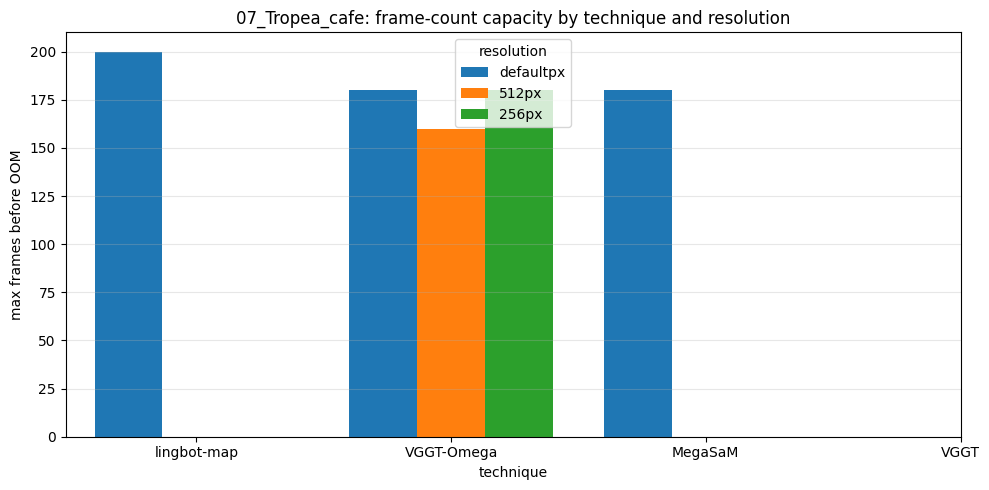

In [15]:
tab10 = plt.cm.tab10.colors
COLOR_MAP = {"default": tab10[0], 512: tab10[1], 256: tab10[2]}

techniques = [t for t in TECHNIQUE_ORDER if t in limits_df["technique"].unique()]
x = np.arange(len(techniques))
width = 0.8 / len(RESOLUTIONS)

fig, ax = plt.subplots(figsize=(10, 5))
for i, resolution in enumerate(RESOLUTIONS):
    sub = limits_df[limits_df["resolution"] == resolution].set_index("technique")["max_frames_ok"]
    heights = [sub.get(t, np.nan) for t in techniques]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=f"{resolution}px",
           color=COLOR_MAP.get(resolution))

ax.set_xticks(x)
ax.set_xticklabels(techniques)
ax.set_xlabel("technique")
ax.set_ylabel("max frames before OOM")
ax.set_title(f"{case_name}: frame-count capacity by technique and resolution")
ax.legend(title="resolution")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()